In [17]:
print("hello")

hello


In [69]:
import os
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.stats import skew, kurtosis



In [70]:
def pre_processed(file_path,window_size=2048,overlap = 0.2):
    mat = scipy.io.loadmat(file_path)
    key = [k for k in mat.keys() if 'DE_time' in k]
    
    signal = mat[key[0]].flatten()
    
    signal = (signal-np.mean(signal))/np.std(signal)
    
    step = int(window_size * (1 - overlap))
    segments = []

    for i in range(0, len(signal) - window_size, step):
        segments.append(signal[i:i+window_size])

    return np.array(segments)

In [71]:
segments_signal = pre_processed("archive/cwru/B007_0.mat")

In [72]:
print(len(segments_signal))

74


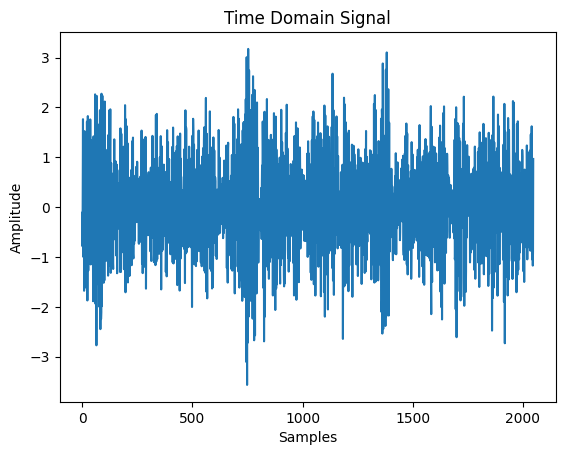

In [73]:
plt.figure()
plt.plot(segments_signal[0])
plt.title("Time Domain Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()
  

In [74]:
def compute_fft(signal):
    N = len(signal)
    fft_vals = fft(signal)
    magnitude = np.abs(fft_vals)[:N//2]
    return magnitude

In [75]:
magnitude= []
for ss in segments_signal:
    magnitude.append(compute_fft(ss))

In [76]:
magnitude

[array([46.42917529,  2.53142014,  2.52668436, ...,  0.61658328,
         0.61942792,  0.62276859]),
 array([46.78998183,  5.46272453,  5.49276767, ...,  0.32646093,
         0.33387432,  0.33076233]),
 array([43.12802979,  3.94374982,  3.95088573, ...,  2.51730771,
         2.51200998,  2.51801343]),
 array([38.14351094,  2.15533602,  1.74454648, ...,  0.18698362,
         0.19465081,  0.17213972]),
 array([36.88771677,  0.30951774,  0.22147315, ...,  0.61532991,
         0.59398936,  0.57136647]),
 array([41.6672319 ,  4.0532142 ,  3.96179502, ...,  0.95793897,
         0.96484314,  0.94450455]),
 array([40.09397484,  3.85230334,  3.78114988, ...,  0.107301  ,
         0.08505406,  0.0996287 ]),
 array([3.48224508e+01, 5.92034663e-01, 3.94184959e-01, ...,
        1.99819984e-02, 1.03179101e-02, 2.61804053e-02]),
 array([31.62673576,  3.80132189,  3.99651201, ...,  1.16412193,
         1.13620325,  1.13665406]),
 array([28.26584632,  6.9394813 ,  6.78590636, ...,  0.33623586,
        

Text(0, 0.5, 'Magnitude')

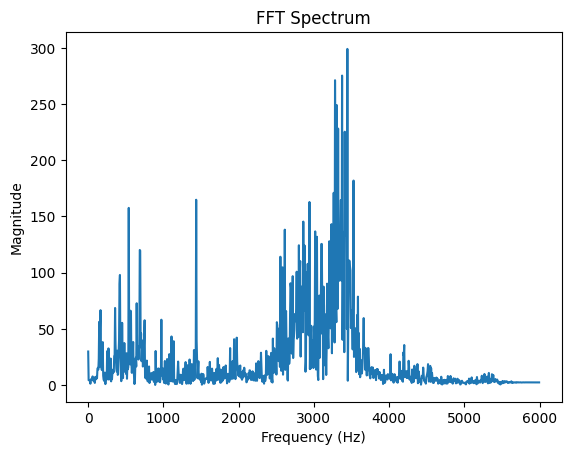

In [ ]:
fs = 12000
N = 2048

freq = np.fft.fftfreq(N, 1/fs)[:N//2]
plt.figure()
plt.plot(freq, magnitude[10])
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

In [78]:
magnitude = np.array(magnitude)

In [81]:
def time_features(x):
    mean = np.mean(x)
    rms = np.sqrt(np.mean(x**2))
    std = np.std(x)
    peak = np.max(np.abs(x))
    ptp = np.ptp(x)
    sk = skew(x)
    kurt = kurtosis(x)
    crest_factor = peak / rms
    shape_factor = rms / np.mean(np.abs(x))
    impulse_factor = peak / np.mean(np.abs(x))
    energy_factor = np.sum(x**2) / len(x)

    return [
        mean,
        rms,
        std,
        crest_factor,
        sk,
        shape_factor,
        kurt,
        ptp,
        energy_factor,
        impulse_factor
    ]

In [82]:
def frequency_features(mag, freq):
    peak_index = np.argmax(mag)
    peak_freq = freq[peak_index]
    peak_to_peak_freq = np.max(freq) - np.min(freq)
    spectral_kurtosis = kurtosis(mag)
    spectral_skewness = skew(mag)
    spectral_bandwidth = np.sqrt(np.sum((freq - np.mean(freq))**2 * mag) / np.sum(mag))
    return [
        peak_freq,
        peak_to_peak_freq,
        spectral_kurtosis,
        spectral_bandwidth,
        spectral_skewness
    ]

In [90]:
T_feature = []
for i in range(len(segments_signal)):
    T_feature.append(time_features(segments_signal[i]))
print(T_feature)
    

[[0.022670495749213513, 0.9643173574768928, 0.964050836083711, 3.6973715836836685, 0.011866016572550667, 1.2424352904344556, -0.10071732565131386, 6.739350634266704, 0.9299079659312175, 4.593744937418122], [0.022846670815088975, 0.9975055395315204, 0.9972438673808611, 3.6671316434107797, -0.021940067435413754, 1.2581588170618228, 0.10311609968461077, 7.2383882442436915, 0.9950173013960696, 4.613834010483685], [0.021058608295846493, 0.9177066074799622, 0.9174649597826741, 3.2903151933879866, -0.002118532027492964, 1.2393062840391176, -0.2848045729136608, 5.811562401633427, 0.8421854174123815, 4.077708295635116], [0.01862476120071636, 1.0045906139550138, 1.004417950813668, 3.8266778441806055, -0.04680464203831831, 1.2357684258956783, -0.14363798655558302, 6.852981263768506, 1.0092023016465115, 4.728887655912935], [0.018011580451955025, 0.9623299709885997, 0.9621613981201604, 3.9947260926979737, -0.055238975131721206, 1.2626702266010987, 0.11879585249749924, 7.047441928689116, 0.926078973

In [92]:
F_feature = []
for j in range(len(magnitude)):   
    F_feature.append(frequency_features(magnitude[j],freq=freq))
print(F_feature)

[[3369.140625, 5994.140625, 15.322591960741207, 1171.3774893903148, 3.495642983362925], [3234.375, 5994.140625, 14.510778996225689, 1182.1573284629228, 3.451462621647608], [3363.28125, 5994.140625, 13.844178013809358, 1237.1286614593691, 3.382199463137634], [3445.3125, 5994.140625, 18.271199710315667, 1160.8744013718556, 3.6840512087143664], [3234.375, 5994.140625, 11.910992830052228, 1172.7584192829343, 3.13788364793144], [3263.671875, 5994.140625, 14.689506690564667, 1159.9863764694312, 3.4576615184132264], [3234.375, 5994.140625, 14.163681166640963, 1142.9924407357785, 3.403834062152837], [3263.671875, 5994.140625, 19.49873403239161, 1153.691794610767, 3.791898302739108], [3275.390625, 5994.140625, 14.539859309929835, 1191.4070319078055, 3.464203892698049], [3246.09375, 5994.140625, 10.430425664912137, 1187.2713213715451, 3.043800498130284], [3445.3125, 5994.140625, 14.82840003191356, 1223.9808158822004, 3.395020122628461], [3369.140625, 5994.140625, 12.793403353350946, 1196.4449284

In [97]:
T_feature = np.array(T_feature)
F_feature = np.array(F_feature)
features = np.hstack((T_feature, F_feature))
print(features)

[[ 2.26704957e-02  9.64317357e-01  9.64050836e-01 ...  1.53225920e+01
   1.17137749e+03  3.49564298e+00]
 [ 2.28466708e-02  9.97505540e-01  9.97243867e-01 ...  1.45107790e+01
   1.18215733e+03  3.45146262e+00]
 [ 2.10586083e-02  9.17706607e-01  9.17464960e-01 ...  1.38441780e+01
   1.23712866e+03  3.38219946e+00]
 ...
 [-1.68813785e-02  1.04663775e+00  1.04650160e+00 ...  2.51114650e+01
   1.08894739e+03  4.09085839e+00]
 [-1.94593689e-02  1.05060134e+00  1.05042111e+00 ...  1.57272432e+01
   1.12458715e+03  3.55661374e+00]
 [-2.03350962e-02  1.07435672e+00  1.07416425e+00 ...  1.76413395e+01
   1.12475968e+03  3.68208241e+00]]
